In [45]:
#Title:
# Sales Data Analysis Project
# Dataset: Amazon Sales Dataset
# Objective: Analyze sales performance and provide business insights


# **DATA ANALYSIS APPROACH**
Data exploration and understanding,Data cleansing (handling missing values,
replacing nulls in the 'Amount' column with the
median),In-depth analysis focusing on revenue,customer behavior, logistics, and returns.

In [46]:
#Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('default')
plt.rcParams['figure.figsize'] = (10,6)


In [47]:
#Loading Dataset

df = pd.read_csv("/content/Sales dataset.csv", low_memory=False)
df


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128944,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,...,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128945,402-9551604-7544318,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,...,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128946,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,...,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False
128947,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,XS,...,INR,1199.00,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [48]:
#Dataset Shape & Info

print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (128949, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-c

In [49]:
#Checking Missing Values

df.isnull().sum().sort_values(ascending=False)

,0
fulfilled-by,89679
promotion-ids,49142
Unnamed: 22,49041
currency,7794
Amount,7794
Courier Status,6871
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33


In [50]:
#Data Cleaning
#Handle Missing Values

# Set Amount to 0 where Status is 'Cancelled'
df.loc[df['Status'].str.contains('Cancelled', na=False), 'Amount'] = 0

# Calculate the median of the Amount column
median_amount = df['Amount'].median()

# Fill the remaining NaN values in the Amount column with the median
df['Amount'].fillna(median_amount, inplace=True)

# Verification
print(f"Median used for filling: {median_amount}")
print(f"Remaining missing values in Amount: {df['Amount'].isnull().sum()}")

Median used for filling: 545.0
Remaining missing values in Amount: 0


In [51]:
#filling null values with 'No Promotion'

df['promotion-ids'].fillna('No Promotion', inplace=True)

# Verify the changes
print(f"Missing values in 'promotion-ids' column after filling: {df['promotion-ids'].isnull().sum()}")

Missing values in 'promotion-ids' column after filling: 0


In [52]:
#fiiling null values with 'unknown'

df['fulfilled-by'].fillna('Unknown', inplace=True)

# Verify the changes
print(f"Missing values in 'fulfilled-by' column after filling: {df['fulfilled-by'].isnull().sum()}")

Missing values in 'fulfilled-by' column after filling: 0


In [53]:
#Finding Unique Values

categorical_cols = ['Status', 'Fulfilment', 'Category', 'Courier Status', 'currency', 'ship-state', 'ship-country']

print("Current columns in DataFrame:")
print(df.columns.tolist())

for col in categorical_cols:
    print(f"\nUnique values for '{col}':")
    print(df[col].unique())
    print(f"Number of unique values: {df[col].nunique()}")

Current columns in DataFrame:
['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

Unique values for 'Status':
['Cancelled' 'Shipped - Delivered to Buyer' 'Shipped'
 'Shipped - Returned to Seller' 'Shipped - Rejected by Buyer'
 'Shipped - Lost in Transit' 'Shipped - Out for Delivery'
 'Shipped - Returning to Seller' 'Shipped - Picked Up' 'Pending'
 'Pending - Waiting for Pick Up' 'Shipped - Damaged' 'Shipping']
Number of unique values: 13

Unique values for 'Fulfilment':
['Merchant' 'Amazon']
Number of unique values: 2

Unique values for 'Category':
['Set' 'kurta' 'Western Dress' 'Top' 'Ethnic Dress' 'Bottom' 'Saree'
 'Blouse' 'Dupatta']
Number of unique values: 9

Unique values for 'Courier Status':
[nan 'Shipped' 'Cancelled' 'Unshipped']
Number o

In [54]:
# Replacing NaN values in Courier Status with 'Unknown'
df['Courier Status'].fillna('Unknown', inplace=True)

# Replacing NaN values in currency with 'INR'
df['currency'].fillna('INR', inplace=True)

# Replacing NaN values in ship-state with 'Unknown'
df['ship-state'].fillna('Unknown', inplace=True)

# Replacing NaN values in ship-country with 'IN'
df['ship-country'].fillna('IN', inplace=True)


print("\nNaN count AFTER filling:\n")
print("Courier Status :", df['Courier Status'].isna().sum())
print("Currency       :", df['currency'].isna().sum())
print("Ship State     :", df['ship-state'].isna().sum())
print("Ship Country   :", df['ship-country'].isna().sum())



NaN count AFTER filling:

Courier Status : 0
Currency       : 0
Ship State     : 0
Ship Country   : 0


In [55]:
# Normalize ship-state text

df['ship-state'] = (
    df['ship-state']
    .str.strip()
    .str.lower()
)

# State name mapping
state_mapping = {
    'maharashtra': 'Maharashtra',
    'karnataka': 'Karnataka',

    'puducherry': 'Puducherry',
    'pondicherry': 'Puducherry',

    'tamil nadu': 'Tamil Nadu',
    'uttar pradesh': 'Uttar Pradesh',

    'delhi': 'Delhi',
    'new delhi': 'Delhi',

    'chandigarh': 'Chandigarh',
    'telangana': 'Telangana',

    'andhra pradesh': 'Andhra Pradesh',
    'apo': 'Andhra Pradesh',

    'odisha': 'Odisha',
    'orissa': 'Odisha',

    'rajasthan': 'Rajasthan',
    'rajsthan': 'Rajasthan',
    'rajshthan': 'Rajasthan',
    'rj': 'Rajasthan',

    'haryana': 'Haryana',

    'punjab': 'Punjab',
    'punjab/mohali/zirakpur': 'Punjab',
    'pb': 'Punjab',

    'goa': 'Goa',
    'gujarat': 'Gujarat',
    'bihar': 'Bihar',

    'arunachal pradesh': 'Arunachal Pradesh',
    'ar': 'Arunachal Pradesh',

    'sikkim': 'Sikkim',
    'madhya pradesh': 'Madhya Pradesh',
    'west bengal': 'West Bengal',
    'kerala': 'Kerala',
    'haryana': 'Haryana',
    'himachal pradesh': 'Himachal Pradesh',
    'uttarakhand': 'Uttarakhand',

    'assam': 'Assam',
    'jharkhand': 'Jharkhand',
    'chhattisgarh': 'Chhattisgarh',
    'jammu & kashmir': 'Jammu & Kashmir',

    'manipur': 'Manipur',
    'mizoram': 'Mizoram',
    'nagaland': 'Nagaland',
    'meghalaya': 'Meghalaya',
    'sikkim': 'Sikkim',
    'tripura': 'Tripura',

    'ladakh': 'Ladakh',
    'lakshadweep': 'Lakshadweep',
    'andaman & nicobar': 'Andaman & Nicobar',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli',
    'dadra and nagar': 'Dadar and Nagar Haveli',
    'daman & diu': 'Daman & Diu',

    'chandigarh': 'Chandigarh',

    'unknown': 'Unknown',
    'nl': 'Unknown'
}

# Apply mapping
df['ship-state'] = df['ship-state'].replace(state_mapping)

# ---------- AFTER CLEANING ----------
print("\nUnique ship-state values AFTER cleaning:")
print(df['ship-state'].unique())
print("Number of unique states (after):", df['ship-state'].nunique())


Unique ship-state values AFTER cleaning:
['Maharashtra' 'Karnataka' 'Puducherry' 'Tamil Nadu' 'Uttar Pradesh'
 'Chandigarh' 'Telangana' 'Assam' 'Jharkhand' 'Chhattisgarh'
 'Andhra Pradesh' 'Odisha' 'Delhi' 'Kerala' 'Madhya Pradesh' 'West Bengal'
 'Nagaland' 'Rajasthan' 'Gujarat' 'Uttarakhand' 'Bihar' 'Jammu & Kashmir'
 'Haryana' 'Punjab' 'Himachal Pradesh' 'Arunachal Pradesh' 'Manipur' 'Goa'
 'Meghalaya' 'Tripura' 'Ladakh' 'Dadar and Nagar Haveli' 'Sikkim'
 'Unknown' 'Andaman & Nicobar' 'Mizoram' 'Lakshadweep']
Number of unique states (after): 37


In [56]:
# Verify missing values after replacement
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 22,49041
ship-city,33
ship-postal-code,33
Fulfilment,0
Order ID,0
Date,0
Status,0
Style,0
ship-service-level,0
Sales Channel,0


In [57]:
#removing 'unnamed:22' columns

if 'Unnamed: 22' in df.columns:
    df = df.drop(columns=['Unnamed: 22'])
    print("Removed 'Unnamed: 22' column.")
else:
    print("'Unnamed: 22' column not found or already removed.")

Removed 'Unnamed: 22' column.


In [58]:
# Fill null values in 'ship-city' with 'Unknown'
df['ship-city'].fillna('Unknown', inplace=True)

# Fill null values in 'ship-postal-code' with 0
df['ship-postal-code'].fillna(0, inplace=True)

# Verify the changes
print("Missing values in 'ship-city' after filling:", df['ship-city'].isnull().sum())
print("Missing values in 'ship-postal-code' after filling:", df['ship-postal-code'].isnull().sum())

Missing values in 'ship-city' after filling: 0
Missing values in 'ship-postal-code' after filling: 0


In [59]:
# Verify missing values after replacement
df.isnull().sum().sort_values(ascending=False)

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [60]:
#Date Formatting & Feature Engineering

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
# ---------- AFTER ----------
print("\nDate column AFTER conversion:")
print(df['Date'])
print("Data type AFTER:", df['Date'].dtype)

print("\nMonth & Year columns (sample):")
print(df[['Date', 'Month', 'Year']])



Date column AFTER conversion:
0        2022-04-30
1        2022-04-30
2        2022-04-30
3        2022-04-30
4        2022-04-30
            ...    
128944   2022-05-31
128945   2022-05-31
128946   2022-05-31
128947   2022-05-31
128948   2022-05-31
Name: Date, Length: 128949, dtype: datetime64[ns]
Data type AFTER: datetime64[ns]

Month & Year columns (sample):
             Date  Month  Year
0      2022-04-30      4  2022
1      2022-04-30      4  2022
2      2022-04-30      4  2022
3      2022-04-30      4  2022
4      2022-04-30      4  2022
...           ...    ...   ...
128944 2022-05-31      5  2022
128945 2022-05-31      5  2022
128946 2022-05-31      5  2022
128947 2022-05-31      5  2022
128948 2022-05-31      5  2022

[128949 rows x 3 columns]


In [61]:
#Basic Statistical Summary

df.describe()

,Date,Qty,Amount,ship-postal-code,Month,Year
count,128949,128949.000000,128949.000000,128949.000000,128949.000000,128949.0
mean,2022-05-12 11:46:37.636274176,0.904629,556.615008,463859.558942,4.909150,2022.0
min,2022-03-31 00:00:00,0.000000,0.000000,0.000000,3.000000,2022.0
25%,2022-04-20 00:00:00,1.000000,376.000000,382421.000000,4.000000,2022.0
50%,2022-05-10 00:00:00,1.000000,545.000000,500033.000000,5.000000,2022.0
75%,2022-06-04 00:00:00,1.000000,760.000000,600024.000000,6.000000,2022.0
max,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000,6.000000,2022.0
std,NaN,0.314782,346.493510,191592.613737,0.818381,0.0


# **FINANCIAL PERFORMANCE ANALYSIS**

# **Analyzing total revenue growth over time.**

In [62]:
#Total Sales Calculation

total_sales = df['Amount'].sum()
print(f"Total Sales: ₹{total_sales:,.2f}")


Total Sales: ₹71,774,948.62


Monthly Revenue (Mar–Jun):
Mar       95355.00
Apr    26278569.62
May    23983543.00
Jun    21417481.00
Name: Amount, dtype: float64


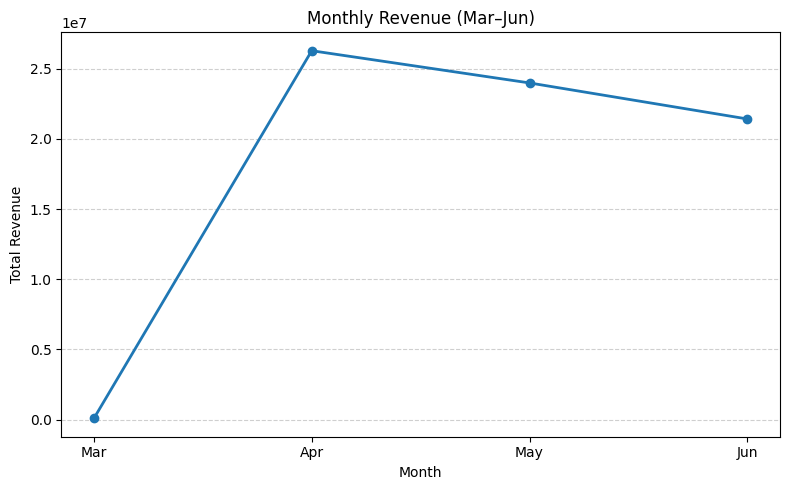

In [63]:
# Revenue by months
df_filtered = df[df['Month'].isin([3,4,5,6])]

# Group revenue
monthly_revenue = df_filtered.groupby('Month')['Amount'].sum()

# Map month names
month_map = {3:'Mar', 4:'Apr', 5:'May', 6:'Jun'}
monthly_revenue.index = monthly_revenue.index.map(month_map)

# Define chronological order
month_order = ['Mar', 'Apr', 'May', 'Jun']
monthly_revenue.index = pd.Categorical(
    monthly_revenue.index,
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_index()

print("Monthly Revenue (Mar–Jun):")
print(monthly_revenue)

# Plot
plt.figure(figsize=(8,5))
plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker='o',
         linewidth=2)

plt.title('Monthly Revenue (Mar–Jun)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

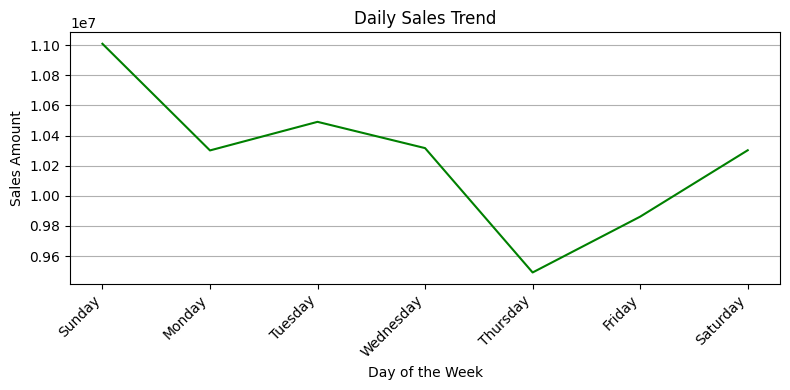

In [64]:
#revenue by Day

df['Day_Name'] = df['Date'].dt.day_name()

daily_sales = df.groupby('Day_Name')['Amount'].sum().reset_index()

day_order = [
    'Sunday','Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday'
]

daily_sales['Day_Name'] = pd.Categorical(
    daily_sales['Day_Name'],
    categories=day_order,
    ordered=True
)

daily_sales = daily_sales.sort_values('Day_Name')

plt.figure(figsize=(8, 4))
plt.plot(daily_sales['Day_Name'], daily_sales['Amount'], color='green')
plt.title("Daily Sales Trend")
plt.xlabel("Day of the Week")
plt.ylabel("Sales Amount")
plt.grid(axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

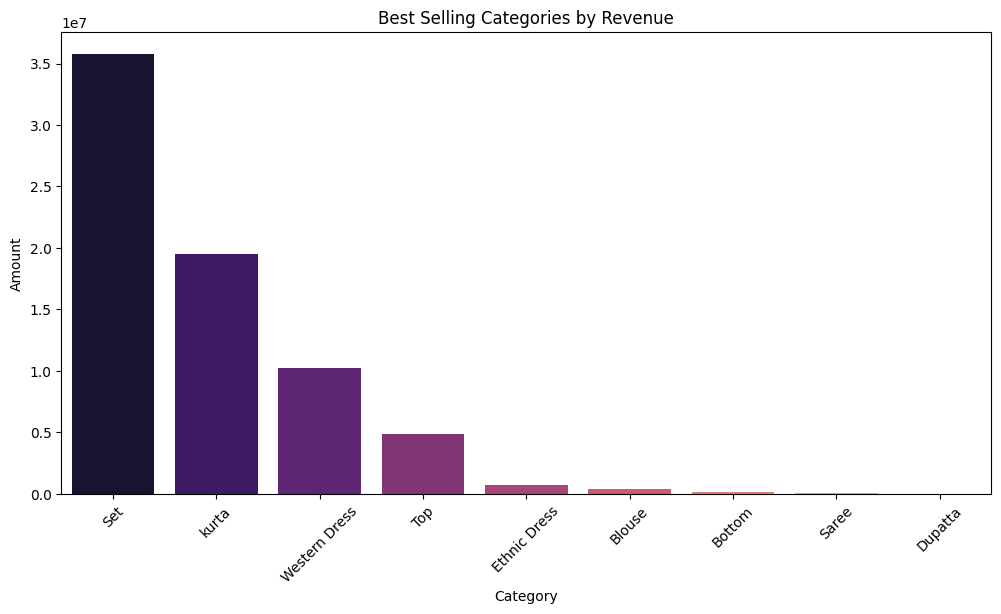

Top 5 Categories by Revenue:
                    Amount    Qty
Category                         
Set            35779587.14  45288
kurta          19473807.48  45049
Western Dress  10208405.00  13943
Top             4908912.00   9902
Ethnic Dress     732061.00   1052


In [65]:
# Group by Category and calculate total Revenue and Quantity


best_sellers = df.groupby('Category').agg({
    'Amount': 'sum',
    'Qty': 'sum'
}).sort_values(by='Amount', ascending=False)

# Plotting the Revenue by Category
plt.figure(figsize=(12, 6))
sns.barplot(x=best_sellers.index, y=best_sellers['Amount'], palette='magma')
plt.title('Best Selling Categories by Revenue')
plt.xticks(rotation=45)
plt.show()

print("Top 5 Categories by Revenue:")
print(best_sellers.head(5))

# **Identifying best-selling products and seasonal sales trends.**

In [66]:
#Best selling products

best_selling = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)
print("Best Selling Products:")
print(best_selling)

Best Selling Products:
Category
Set              45288
kurta            45049
Western Dress    13943
Top               9902
Ethnic Dress      1052
Blouse             864
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64


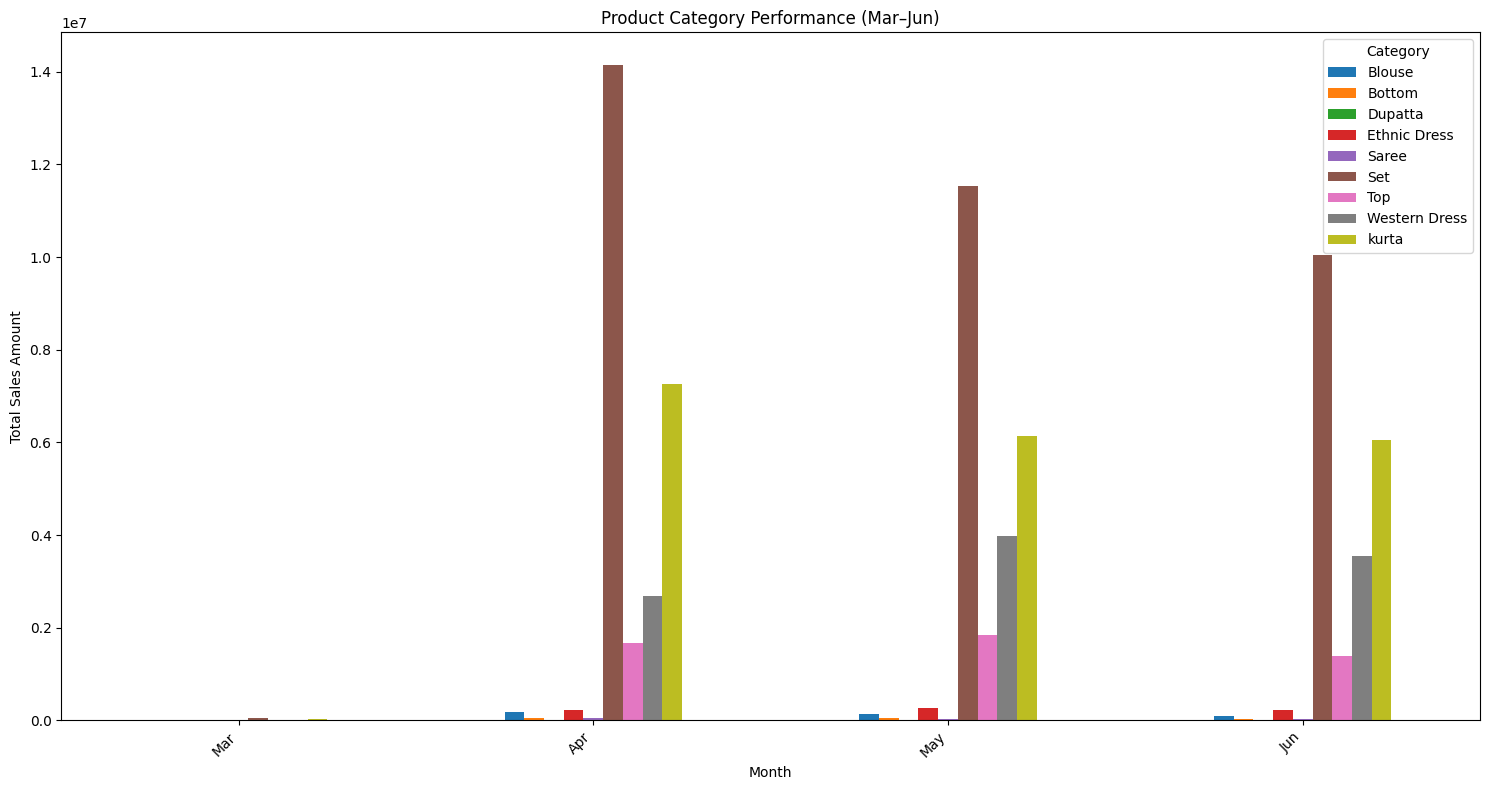

In [67]:
# Pivot table to see Category sales per Month
# Filter only Mar(3), Apr(4), May(5), Jun(6)
df_filtered = df[df['Month'].isin([3,4,5,6])]

# Create Pivot Table
seasonal_pivot = df_filtered.pivot_table(
    index='Month', # Use Month (numerical) for indexing initially
    columns='Category',
    values='Amount',
    aggfunc='sum'
).fillna(0)

# Map numerical months to abbreviated month names for display
month_map = {3:'Mar', 4:'Apr', 5:'May', 6:'Jun'}
seasonal_pivot.index = seasonal_pivot.index.map(month_map)

# Plot
seasonal_pivot.plot(kind='bar', figsize=(15,8))

plt.title('Product Category Performance (Mar–Jun)')
plt.xlabel('Month') # Changed label from Month-Year
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Calculating the average order value to understand spending behavior.**

In [68]:
# 1. Calculate Total Revenue (Sum of cleaned Amount column)
total_revenue = df['Amount'].sum()

# 2. Calculate Total Number of Unique Orders
total_orders = df['Order ID'].nunique()

# 3. Calculate Average Order Value (AOV)
aov = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Average Order Value (AOV): {aov:.2f}")

# Optional: Mean of the Amount column (average per transaction)
print(f"Average Transaction Amount: {df['Amount'].mean():.2f}")

Total Revenue: 71,774,948.62
Total Unique Orders: 120352
Average Order Value (AOV): 596.38
Average Transaction Amount: 556.62


##Summary
Analysis of Spending Behavior Based on the dataset:

Average Order Value (AOV): $596.38$: This indicates that on average, each unique order brings in approximately $596$.

Transaction vs. Order: The Average Transaction Amount ($556.62$) is slightly lower than the AOV.

This is because some orders may contain multiple items or transactions, and the AOV looks at the value per unique Order ID.

Business Impact:
High AOV: Suggests customers are buying premium products or multiple items per order.

Low AOV: Suggests a need for "Upselling" or "Bundling" strategies (e.g., "Buy 2 Kurtas and get 10% off") to increase the revenue per order.

# **CUSTOMER INSIGHTS ANALYSIS**

# **Identifying top-performing locations based on sales volume.**

Top 5 States by Revenue:
ship-state
Maharashtra      12234115.00
Karnataka         9648329.00
Telangana         6293653.57
Uttar Pradesh     6185048.00
Tamil Nadu        5958817.00
Name: Amount, dtype: float64
Top 5 Cities by Revenue:
ship-city
BENGALURU    6349713.00
HYDERABAD    4499883.57
MUMBAI       3400494.00
NEW DELHI    3331168.48
CHENNAI      2823610.00
Name: Amount, dtype: float64


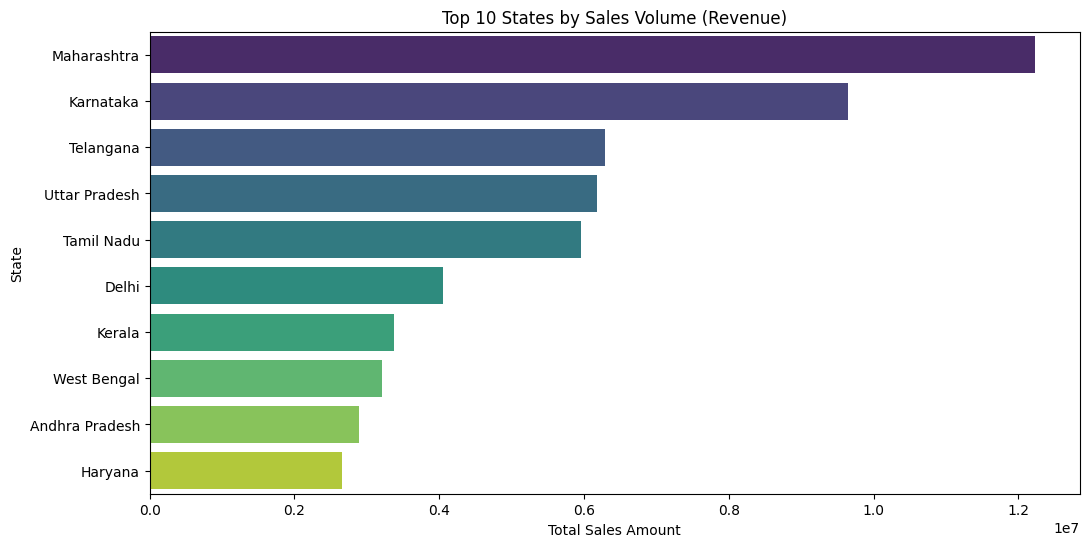

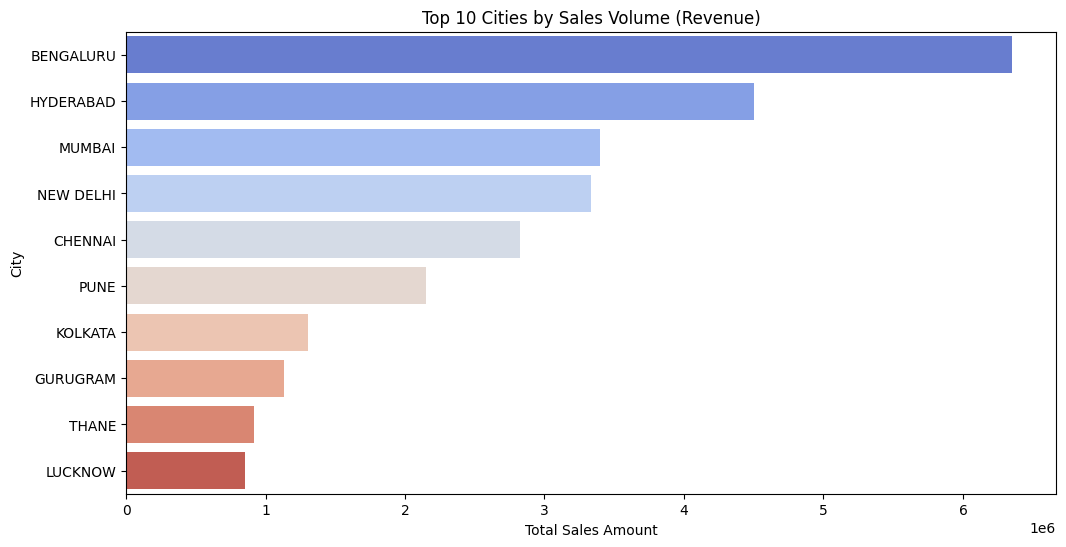

In [69]:
# 1. Group by State to find top-performing states

top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

# 2. Group by City to find top-performing cities
top_cities = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

print("Top 5 States by Revenue:")
print(top_states.head(5))

print("Top 5 Cities by Revenue:")
print(top_cities.head(5))

# 3. Visualization: Top 10 States
plt.figure(figsize=(12, 6))
sns.barplot(x=top_states.values, y=top_states.index, palette='viridis')
plt.title('Top 10 States by Sales Volume (Revenue)')
plt.xlabel('Total Sales Amount')
plt.ylabel('State')
plt.show()

# 4. Visualization: Top 10 Cities
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='coolwarm')
plt.title('Top 10 Cities by Sales Volume (Revenue)')
plt.xlabel('Total Sales Amount')
plt.ylabel('City')
plt.show()


# **Analyzing order cancellation trends and customer retention.**

In [70]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Year'] = df['Date'].dt.to_period('M')

# Clean Status column (re-add to ensure consistency)
df['Status'] = df['Status'].str.strip().str.lower()

#cancelled orders
cancelled_orders = (
    df[df['Status'] == 'cancelled']
      .groupby('Month')['Status']
      .count()
)

#total orders
total_orders = (
    df['Order ID'].nunique()
)

# Calculate monthly cancellation rate directly for the comparison DataFrame
monthly_cancellation_rate = (cancelled_orders / total_orders) * 100

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({"total_orders": total_orders,
                              "cancelled_orders": cancelled_orders,
                              "cancellation_rate (%)": monthly_cancellation_rate})


# Reset index to make 'Month' a column
comparison_df = comparison_df.reset_index()

# Convert the Month column from integer to Month Name and Year
month_map_full = {3: 'March 2022', 4: 'April 2022', 5: 'May 2022', 6: 'June 2022'}
comparison_df['Month'] = comparison_df['Month'].map(month_map_full)

print(comparison_df)

        Month  total_orders  cancelled_orders  cancellation_rate (%)
0  March 2022        120352                18               0.014956
1  April 2022        120352              7139               5.931767
2    May 2022        120352              5881               4.886500
3   June 2022        120352              5303               4.406242


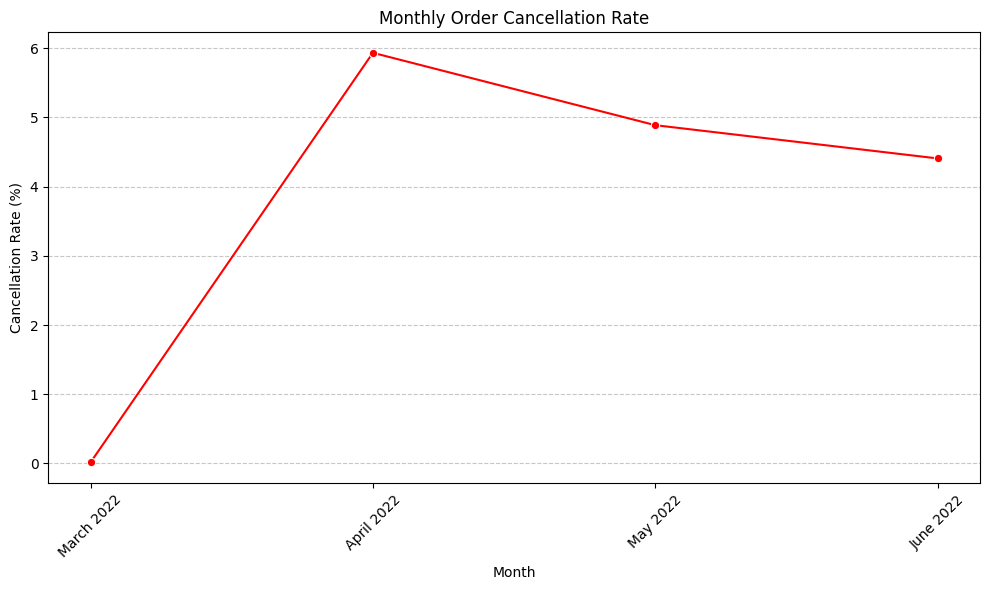

In [71]:
# Plotting the monthly cancellation rate with month names
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='cancellation_rate (%)', data=comparison_df, marker='o', color='red')
plt.title('Monthly Order Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Differentiating B2B vs. B2C customer behavior for targeted marketing.**

## Analyze B2B vs. B2C Sales Distribution


In [72]:
b2b_orders = df[df['B2B'] == True]
b2c_orders = df[df['B2B'] == False]

b2b_series = pd.Series({
    "Total Orders": b2b_orders['Order ID'].count(),
    "Total Revenue": b2b_orders['Amount'].sum(),
    "Total Quantity": b2b_orders['Qty'].sum(),
    "Average Order Value": b2b_orders['Amount'].mean(),
    "Average Quantity per Order": b2b_orders['Qty'].mean()
})

b2c_series = pd.Series({
    "Total Orders": b2c_orders['Order ID'].count(),
    "Total Revenue": b2c_orders['Amount'].sum(),
    "Total Quantity": b2c_orders['Qty'].sum(),
    "Average Order Value": b2c_orders['Amount'].mean(),
    "Average Quantity per Order": b2c_orders['Qty'].mean()
})

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({"B2B": b2b_series, "B2C": b2c_series})
comparison_df

,B2B,B2C
Total Orders,871.000000,1.280780e+05
Total Revenue,559945.000000,7.121500e+07
Total Quantity,841.000000,1.158100e+05
Average Order Value,642.876005,5.560284e+02
Average Quantity per Order,0.965557,9.042146e-01


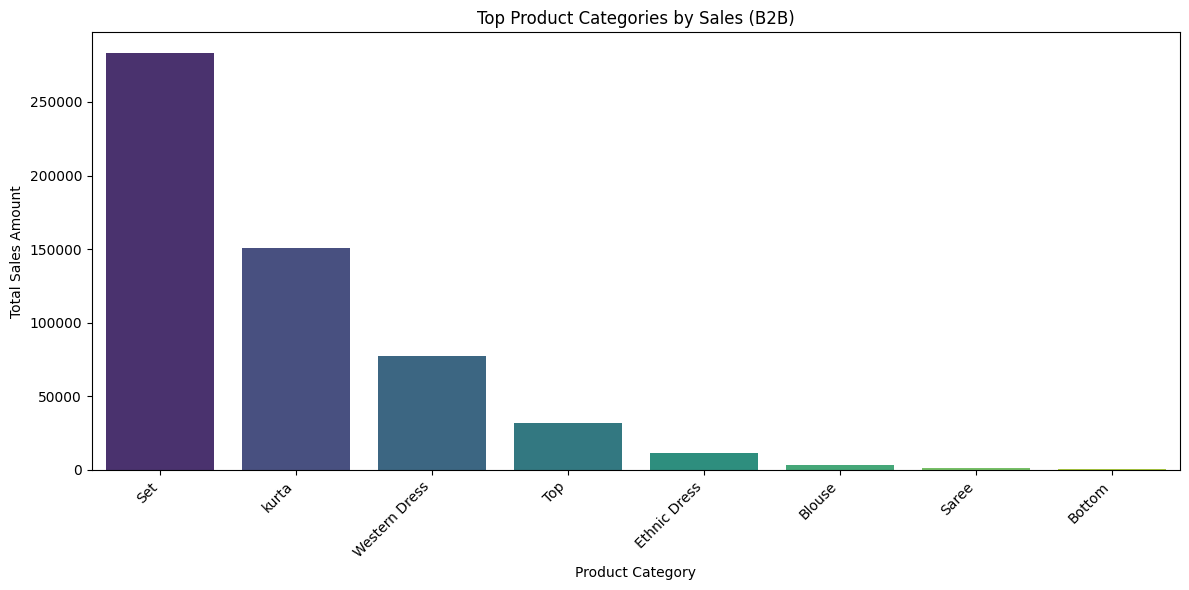

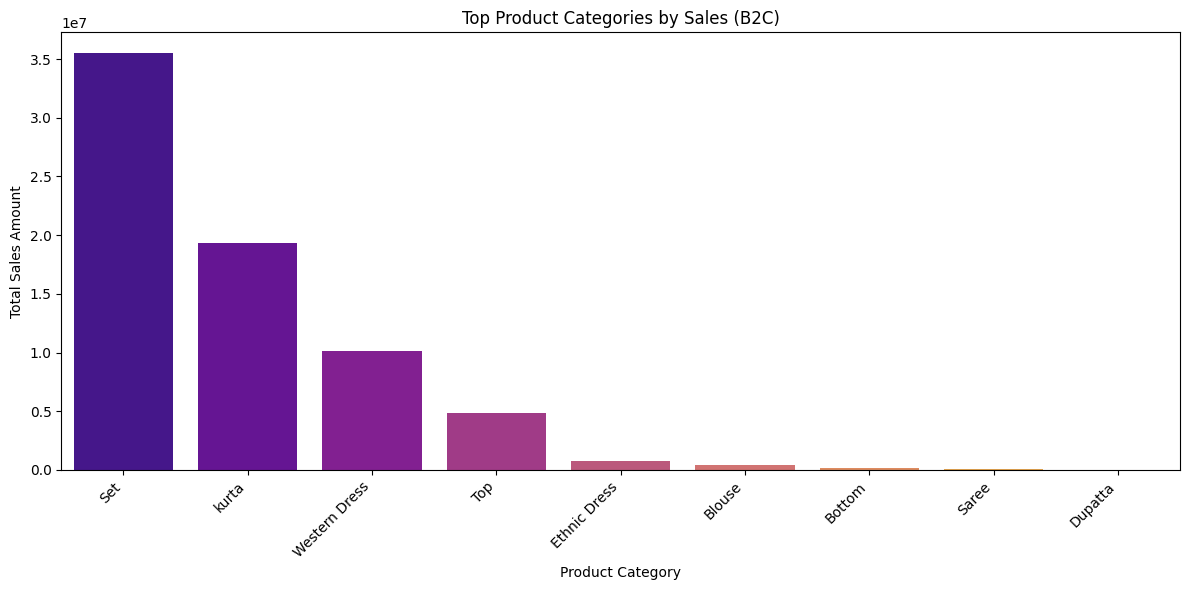


Top 5 B2B Product Categories by Sales:
Category
Set              283146.0
kurta            150701.0
Western Dress     77068.0
Top               31619.0
Ethnic Dress      11826.0
Name: Amount, dtype: float64

Top 5 B2C Product Categories by Sales:
Category
Set              35496441.14
kurta            19323106.48
Western Dress    10131337.00
Top               4877293.00
Ethnic Dress       720235.00
Name: Amount, dtype: float64


In [73]:
#Top product category sales by B2B and B2C

df_b2b = df[df['B2B'] == True]
df_b2c = df[df['B2B'] == False]

b2b_category_sales = df_b2b.groupby('Category')['Amount'].sum().sort_values(ascending=False)
b2c_category_sales = df_b2c.groupby('Category')['Amount'].sum().sort_values(ascending=False)

# Visualization for B2B
plt.figure(figsize=(12, 6))
sns.barplot(x=b2b_category_sales.index, y=b2b_category_sales.values, palette='viridis')
plt.title('Top Product Categories by Sales (B2B)')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization for B2C
plt.figure(figsize=(12, 6))
sns.barplot(x=b2c_category_sales.index, y=b2c_category_sales.values, palette='plasma')
plt.title('Top Product Categories by Sales (B2C)')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 B2B Product Categories by Sales:")
print(b2b_category_sales.head(5))

print("\nTop 5 B2C Product Categories by Sales:")
print(b2c_category_sales.head(5))

# **LOGISTICS & FULFILLMENT OPTIMIZATION**

# **Analyze Ship Service Level Distribution**





Unique ship-service-level values:
['Standard' 'Expedited']

Frequency of each ship-service-level:
ship-service-level
Expedited    88596
Standard     40353
Name: count, dtype: int64


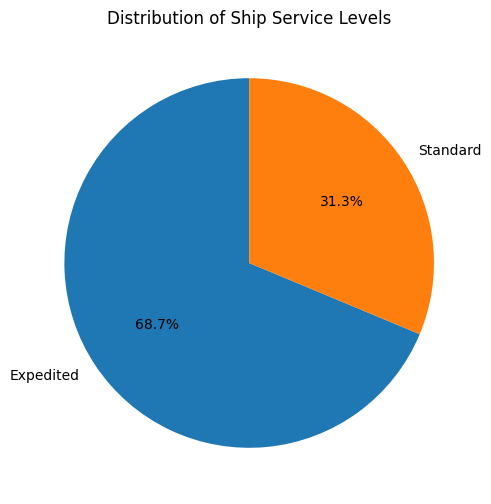

In [74]:
#analyse
print("Unique ship-service-level values:")
print(df['ship-service-level'].unique())

print("\nFrequency of each ship-service-level:")
print(df['ship-service-level'].value_counts())

#visualise
df['ship-service-level'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Distribution of Ship Service Levels')
plt.ylabel('') # Remove default y-label
plt.show()

In [75]:
#Addressing shipping delays by calculating average shipping times

shipped_orders = df[
    df['Status'].str.contains("shipped", case=False, na=False) &
    df['Courier Status'].notna()
]

# Analyze courier status distribution
courier_status_counts = shipped_orders['Courier Status'].value_counts()
courier_status_counts

,count
Courier Status,
Shipped,109436
Unshipped,116
Cancelled,94
Unknown,15


# **Comparing orders fulfilled by Amazon vs. Merchant fulfillment.**

In [76]:
# Compare fulfillment type with courier performance
fulfillment_courier = shipped_orders.groupby('Fulfilment')['Courier Status'].value_counts().unstack(fill_value=0)
fulfillment_courier


Courier Status,Cancelled,Shipped,Unknown,Unshipped
Fulfilment,,,,
Amazon,94,77567,0,116
Merchant,0,31869,15,0


In [77]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format="%m-%d-%y", errors='coerce')

# Extract shipping timeline using 'Date' and infer delivery speed categories
# Since we don't have delivery timestamps, we’ll rely on 'ship-service-level'
shipping_speed = df[df['Status'].str.contains("shipped", case=False, na=False)]

# Average daily order volume per fulfillment type for process improvement insights
order_volume_by_fulfillment = (
    shipping_speed.groupby('Fulfilment')
    .resample('D', on='Date')
    .size()
    .groupby('Fulfilment')
    .mean()
)

# Distribution of ship service levels
service_level_dist = shipping_speed['ship-service-level'].value_counts()

order_volume_by_fulfillment, service_level_dist

(Fulfilment
 Amazon      854.692308
 Merchant    358.247191
 dtype: float64,
 ship-service-level
 Expedited    76752
 Standard     32909
 Name: count, dtype: int64)

In [78]:
# To compare the total sales amount and quantity of items sold for each,
# fulfillment method, I will group the DataFrame by the 'Fulfilment' column
 # and sum both the 'Amount' and 'Qty' columns.**

fulfillment_sales_qty = df.groupby('Fulfilment').agg({
    'Amount': 'sum',
    'Qty': 'sum'
})

print("Sales Amount and Quantity by Fulfillment Method:")
print(fulfillment_sales_qty)

Sales Amount and Quantity by Fulfillment Method:
                 Amount    Qty
Fulfilment                    
Amazon      50692865.00  84086
Merchant    21082083.62  32565


**#Improving order processing for faster deliveries.**

***Since the dataset doesn't have a 'Delivery Date' column, we can't directly measure average shipping times or delays.***

# **PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION**

:
To display the top product categories by sales, I will show the `category_sales` Series, which has already been calculated and sorted in descending order by sales amount.



Top Product Categories by Sales:
Category
Set              35779587.14
kurta            19473807.48
Western Dress    10208405.00
Top               4908912.00
Ethnic Dress       732061.00
Blouse             420569.00
Bottom             135998.00
Saree              114694.00
Dupatta               915.00
Name: Amount, dtype: float64


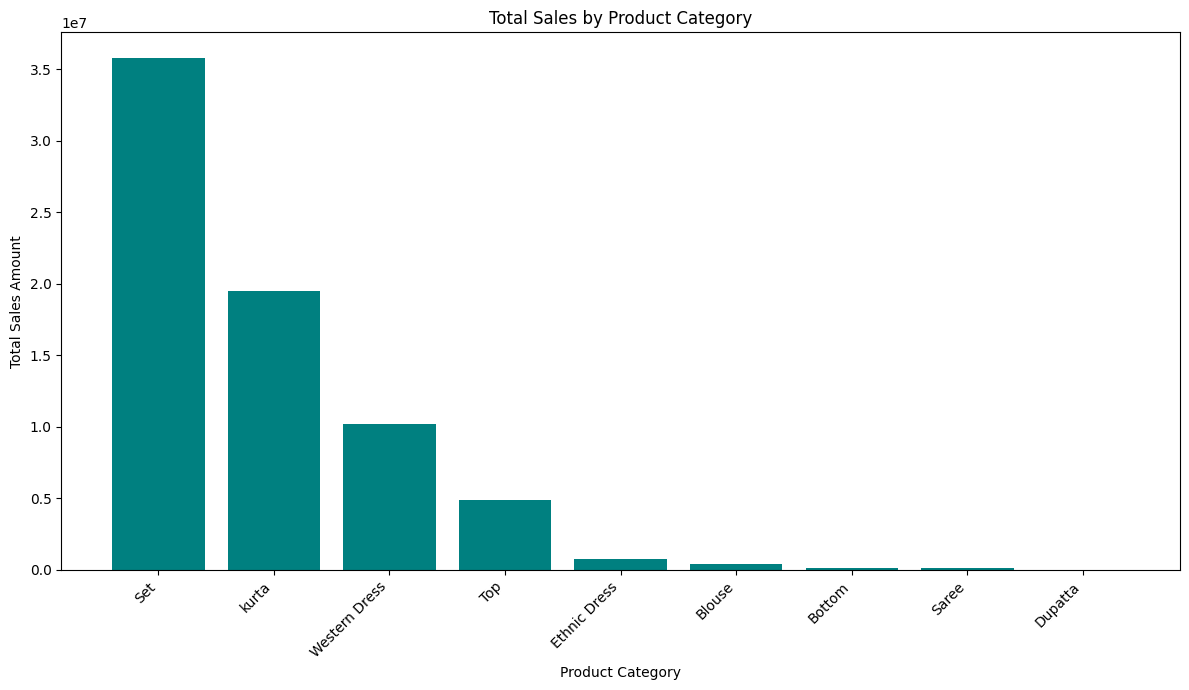

In [79]:
#analyse
# The variable category_sales was not defined.
# Using best_sellers['Amount'] which contains the total sales by product category.
category_sales = best_sellers['Amount']
print("Top Product Categories by Sales:")
print(category_sales)

#visualise
plt.figure(figsize=(12, 7))
plt.bar(category_sales.index, category_sales.values, color='teal')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [80]:
#Analyzing the average quantity ordered for efficient stock management

Average_Qty_Per_Order = df.groupby('Category').agg(
    Total_Orders=('Order ID', 'count'),
    Average=('Qty', 'mean')
).sort_values(by='Total_Orders', ascending=False)
Average_Qty_Per_Order

,Total_Orders,Average
Category,,
Set,50275,0.900806
kurta,49867,0.903383
Western Dress,15495,0.899839
Top,10621,0.932304
Ethnic Dress,1158,0.908463
Blouse,926,0.933045
Bottom,440,0.904545
Saree,164,0.926829
Dupatta,3,1.000000


##**Enhancing inventory control to prevent stockouts or overstocking**

1.Critical Stock Categories:

Set and Kurta: Require active inventory monitoring due to high demand.
Consider dynamic restocking (weekly/monthly) based on rolling average sales.
2.Low Velocity / Overstock Risk:

Dupatta, Saree, Bottom: Low order count and volume. Optimize stocking and avoid bulk replenishment.
3.Stocking Strategy:

Maintain a "min-max" stock level policy using historical average quantity and sales velocity.
Example: If Kurtas sell ~1 per order, and 45,000 units were sold in total, keep safety stock based on peak season sales rate.

# **CUSTOMER SATISFACTION & RETURNS**

## **Investigating high return and cancellation**

In [81]:
# Normalize status column for analysis
df['Status'] = df['Status'].str.lower()

# Flag cancellations and returns
df['is_cancelled'] = df['Status'].str.contains("cancel", na=False)
df['is_returned'] = df['Status'].str.contains("return", na=False)

# Group by product category
category_issues = df.groupby('Category').agg(
    Total_Orders=('Order ID', 'count'),
    Cancelled_Orders=('is_cancelled', 'sum'),
    Returned_Orders=('is_returned', 'sum')
)

# Calculate cancellation and return rates
category_issues['Cancellation Rate (%)'] = (category_issues['Cancelled_Orders'] / category_issues['Total_Orders']) * 100
category_issues['Return Rate (%)'] = (category_issues['Returned_Orders'] / category_issues['Total_Orders']) * 100

# Sort by highest combined issue rate
category_issues['Total Issue Rate (%)'] = category_issues['Cancellation Rate (%)'] + category_issues['Return Rate (%)']
category_issues_sorted = category_issues.sort_values(by='Total Issue Rate (%)', ascending=False)

category_issues_sorted

,Total_Orders,Cancelled_Orders,Returned_Orders,Cancellation Rate (%),Return Rate (%),Total Issue Rate (%)
Category,,,,,,
Set,50275,7338,839,14.595724,1.668821,16.264545
kurta,49867,7259,750,14.556721,1.504001,16.060722
Western Dress,15495,2125,342,13.714101,2.207164,15.921265
Bottom,440,60,6,13.636364,1.363636,15.000000
Ethnic Dress,1158,146,16,12.607945,1.381693,13.989637
Blouse,926,116,12,12.526998,1.295896,13.822894
Saree,164,21,1,12.804878,0.609756,13.414634
Top,10621,1276,132,12.013935,1.242821,13.256755
Dupatta,3,0,0,0.000000,0.000000,0.000000


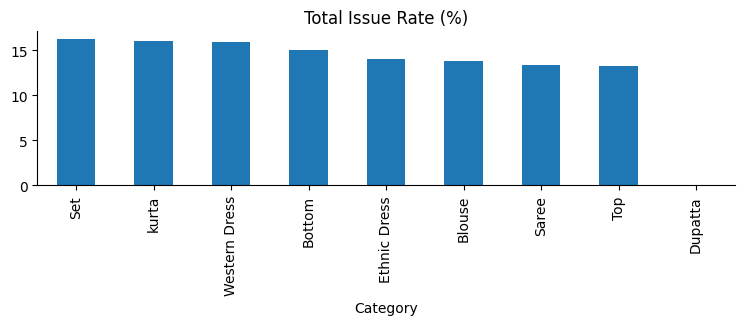

In [82]:
#Total issue rate percent.

category_issues_sorted['Total Issue Rate (%)'].plot(kind='bar', figsize=(9, 2), title='Total Issue Rate (%)')
plt.gca().spines[['top', 'right']].set_visible(False)

#**Identifying problematic products/categories to enhance quality**

**Set**, **Kurta**, **Western Dress**, **Bottom** are the most problematic categories each with 15 - 16% Issue Rate.



# **Improving customer experience through better service policies.**

1. **Product Quality Checks**

  *   High returns indicate possible fit/size issues or misleading photos/
  descriptions.
  *   Prioritize QC for Sets, Kurtas, and Western Dresses.
2.   **Size & Fit Guidance**

  *   Include detailed size charts, model sizing references, and customer feedback summaries on product pages.

3.   **Flexible Cancellation/Return Windows**

  *   Early cancellations may be due to buyer’s remorse or unclear shipping expectations.
  *   Consider adding "cancel within 1 hour" button to reduce downstream fulfillment waste.

4.   **Enhanced Product Descriptions**

  *   For top-cancelled SKUs, review and revise product titles, images, fabric info, and return policy visibility.

# **Conclusion**

The analysis of the e-commerce sales dataset revealed several important business insights.

Revenue showed a **strong peak in April 2022**, followed by a slight decline in later months. Product categories like **Set and Kurta** generated the highest sales, making them key products for the business. In contrast, categories like **Dupatta, Saree, and Bottom** showed lower demand and require better inventory planning.

Customer analysis indicated that **Maharashtra, Karnataka, and Tamil Nadu** are the top-performing states, while **Bengaluru, Hyderabad, and Mumbai** generate the most orders. The data also showed differences between **B2B and B2C customers**, suggesting the need for different marketing strategies.

Return and cancellation rates are relatively high in some product categories, highlighting the need to improve **product quality, sizing accuracy, and descriptions**.

Overall, the analysis demonstrates that **using data-driven insights can help the company optimize operations, improve customer satisfaction, and support long-term business growth.**


-------
# **Recommendations**

1. **Reduce Returns & Cancellations**
   Improve product quality, sizing information, and descriptions for high-issue categories like **Set, Kurta, Western Dress, and Bottom**.

2. **Optimize Inventory Management**
   Increase stock for high-demand products like **Set and Kurta**, and reduce inventory for low-demand items such as **Dupatta and Saree** to avoid overstocking.

3. **Improve Order Fulfillment Efficiency**
   Investigate **unshipped Amazon orders** and resolve fulfillment delays to improve customer satisfaction.

4. **Leverage Amazon Fulfillment for High Sales Products**
   Since Amazon handles higher daily order volumes, use **Amazon fulfillment for high-volume SKUs** to increase operational efficiency.

5. **Use Data for Business Decisions**
   Continue applying **data-driven strategies** to improve operations, manage inventory, and enhance customer experience.

6. **Target High-Performing Markets**
   Focus marketing efforts on **top states and cities** where most sales are generated.




In [83]:
# Save the cleaned dataframe to a new CSV file
df.to_csv('/content/cleaned_sales_dataset.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


MCQ Questions.

In [84]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Year'] = df['Date'].dt.to_period('M')

# Clean Status column (re-add to ensure consistency)
df['Status'] = df['Status'].str.strip().str.lower()

#cancelled orders
cancelled_orders = (
    df[df['Status'] == 'cancelled']
      .groupby('Month')['Status']
      .count()
)

#total orders
total_orders = (
    df['Order ID'].nunique()
)

# Calculate monthly cancellation rate directly for the comparison DataFrame
monthly_cancellation_rate = (cancelled_orders / total_orders) * 100

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({"total_orders": total_orders,
                              "cancelled_orders": cancelled_orders,
                              "cancellation_rate (%)": monthly_cancellation_rate})


# Reset index to make 'Month' a column
comparison_df = comparison_df.reset_index()

# Convert the Month column from integer to Month Name and Year
month_map_full = {3: 'March 2022', 4: 'April 2022', 5: 'May 2022', 6: 'June 2022'}
comparison_df['Month'] = comparison_df['Month'].map(month_map_full)

print(comparison_df)

        Month  total_orders  cancelled_orders  cancellation_rate (%)
0  March 2022        120352                18               0.014956
1  April 2022        120352              7139               5.931767
2    May 2022        120352              5881               4.886500
3   June 2022        120352              5303               4.406242


In [85]:
#Highest sales day

df['Day_Name'] = df['Date'].dt.day_name()

day_sales = df.groupby('Day_Name')['Amount'].sum().reset_index()

day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

day_sales['Day_Name'] = pd.Categorical(
    day_sales['Day_Name'],
    categories=day_order,
    ordered=True
)

day_sales = day_sales.sort_values('Day_Name')
day_sales

day_sales.sort_values('Amount', ascending=False)

,Day_Name,Amount
3,Sunday,11009906.00
5,Tuesday,10491355.00
6,Wednesday,10316875.00
2,Saturday,10302682.62
1,Monday,10301495.00
0,Friday,9861726.00
4,Thursday,9490909.00


In [98]:
#Total Cancelled Orders

total_cancelled_orders = df[df['Status'] == 'cancelled'].shape[0]
print(f"Total Cancelled Orders: {total_cancelled_orders}")

Total Cancelled Orders: 18341


In [87]:
size_quantity = (
    df
    .groupby('Size')['Qty']
    .sum()
    .reset_index()
    .sort_values('Qty', ascending=False)
)

size_quantity


,Size,Qty
6,M,20450
5,L,19993
8,XL,18929
10,XXL,16511
7,S,15337
0,3XL,13526
9,XS,9939
3,6XL,688
2,5XL,513
1,4XL,397


In [88]:
m_set_quantity = df[
    (df['Size'] == 'M') & (df['Category'] == 'Set')
]['Qty'].sum()

print("Total quantity sold for M size in Set category:", m_set_quantity)


Total quantity sold for M size in Set category: 8358


In [89]:
amount_median = df['Amount'].median()

print("Median value of Amount column:", amount_median)



Median value of Amount column: 545.0
